# Gradient Descent Chapter 7 Workshop 4

In [11]:
"""
find (w,b) from y = w*x + b
sample equation : y = 2*x + 0
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid") # Set seaborn plotting style

# Generate some sample data
np.random.seed(seed=1)          # specific random seed
x = np.random.uniform(0, 1, 12)  # uniformly distributed between 0 - 1

# function f(x) = 2*x + 0
def f(x):
    return 2 * x + 0
# define Noise
noise = 0.15
noise = np.random.randn(x.shape[0]) * noise

# Generate y values with noise
y = f(x) + noise

In [12]:
print(type(noise))

<class 'numpy.ndarray'>


## Scatter Ploting Sample Data

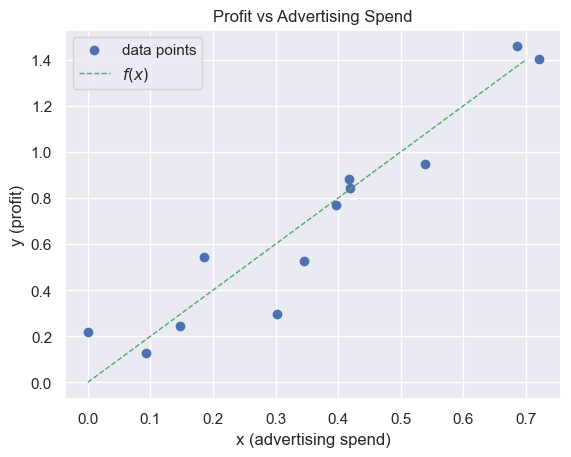

In [13]:
plt.scatter(x, y, marker='o', label='data points')
plt.plot([0, .7], [f(0), 1.4], '--g', lw=1, label='$f(x)$')
plt.xlabel('x (advertising spend)')
plt.ylabel('y (profit)')

plt.title('Profit vs Advertising Spend')
plt.legend(loc=2)
plt.show()

## Create function output from Neuron and MSE function

In [14]:
def neuron(x, w):
    # output functiomn is from neuron : sample y = w*x + b
    return w * x + 0

def loss_mse(y_pred, y_true):
    # Mean Squared Error
    return np.mean((y_pred - y_true) ** 2)

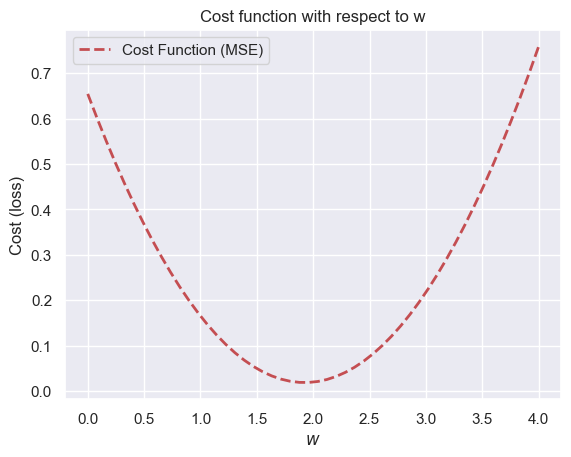

In [15]:
# Create Vector Weight for ploting loss from loss_mse function's MSE

# Create data 0-4 with 50 samples
ws = np.linspace(0, 4, 50)  # weight vector
# calculate all loss and plot all ws
loss_ws = [loss_mse(neuron(x, w), y) for w in ws]

# plot
plt.plot(ws, loss_ws, 'r--', lw=2, label='Cost Function (MSE)')
plt.xlabel('$w$', fontsize=12)
plt.ylabel('Cost (loss)', fontsize=12)
plt.title('Cost function with respect to w')
plt.legend()
plt.show()

In [16]:
print(type(ws))
print(type(loss_ws))
print(loss_ws)

<class 'numpy.ndarray'>
<class 'list'>
[np.float64(0.6544143148025267), np.float64(0.6016012643249412), np.float64(0.5510776446088544), np.float64(0.5028434556542661), np.float64(0.4568986974611764), np.float64(0.41324337002958517), np.float64(0.37187747335949234), np.float64(0.3328010074508983), np.float64(0.29601397230380266), np.float64(0.2615163679182056), np.float64(0.22930819429410707), np.float64(0.19938945143150708), np.float64(0.17176013933040554), np.float64(0.14642025799080263), np.float64(0.12336980741269819), np.float64(0.10260878759609238), np.float64(0.084137198540985), np.float64(0.06795504024737618), np.float64(0.05406231271526594), np.float64(0.0424590159446542), np.float64(0.03314514993554101), np.float64(0.026120714687926344), np.float64(0.021385710201810227), np.float64(0.018940136477192643), np.float64(0.018783993514073588), np.float64(0.020917281312453073), np.float64(0.025339999872331084), np.float64(0.03205214919370764), np.float64(0.04105372927658275), np.floa

## Find w, b

In [17]:
from sklearn import linear_model
lm = linear_model.LinearRegression()
X = x.reshape(-1, 1)  # Reshape x to be a 2D array

lm.fit(X, y)  # Fit the model

# w, b
print(lm.coef_, lm.intercept_)  # Coefficient (slope)

[1.87331728] 0.02454657084406997


In [18]:
print(x.shape)
print(X.shape)

(12,)
(12, 1)


In [25]:
# Gradient function
def gradient(w, x, y_true):
    y_pred = neuron(x, w)
    # Gradient of MSE
    return 2 * (y_pred - y_true) * x

# Update function delta w
def delta_w(w_k, x, y, learning_rate=0.01):
    # Gradient descent
    return learning_rate * np.mean(gradient(w_k, x, y))

# define intial w
w = 3.7

lerning_rate = 0.9

no_of_iterations = 20

# Store track of weight, loss
history_loss = [(w, loss_mse(neuron(x, w), y))]

for i in range(no_of_iterations):
    dw = delta_w(w, x, y, lerning_rate)
    # update w  ( "- dw" mean y_pred value more than y_true)
    w = w - dw
    # Store weight and loss
    history_loss.append((w, loss_mse(neuron(x, w), y)))

# Print weight and loss
for w, loss in history_loss:
    print(f"w: {w:.2f}, loss: {loss:.2f}")


w: 3.70, loss: 0.56
w: 3.15, loss: 0.28
w: 2.77, loss: 0.14
w: 2.51, loss: 0.08
w: 2.33, loss: 0.05
w: 2.20, loss: 0.03
w: 2.12, loss: 0.02
w: 2.06, loss: 0.02
w: 2.02, loss: 0.02
w: 1.99, loss: 0.02
w: 1.97, loss: 0.02
w: 1.95, loss: 0.02
w: 1.94, loss: 0.02
w: 1.94, loss: 0.02
w: 1.93, loss: 0.02
w: 1.93, loss: 0.02
w: 1.93, loss: 0.02
w: 1.93, loss: 0.02
w: 1.93, loss: 0.02
w: 1.93, loss: 0.02
w: 1.93, loss: 0.02


## Plotting  gradient

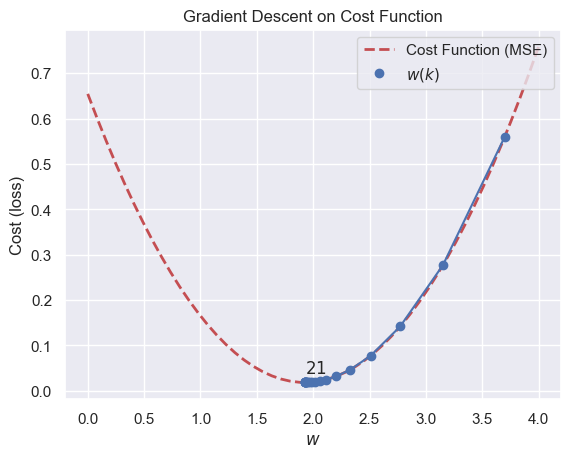

In [26]:
plt.plot(ws, loss_ws, 'r--', lw=2, label='Cost Function (MSE)')
for i in range(len(history_loss)-1):
    w1 ,c1 = history_loss[i]
    w2 ,c2 = history_loss[i+1]
    plt.plot(w1, c1, 'bo')
    plt.plot([w1, w2], [c1, c2], 'b-')
    # plt.text(w1, c1+0.02, f'${i+1}$')

plt.plot(w2, c2, 'bo', label='$w(k)$')
plt.text(w2, c2+0.02, f'${i+2}$')

plt.xlabel('$w$', fontsize=12)
plt.ylabel('Cost (loss)', fontsize=12)
plt.title('Gradient Descent on Cost Function')
plt.legend(loc=1)
plt.show()

# Epoch of Gradient Chapter 7 Workshop 5

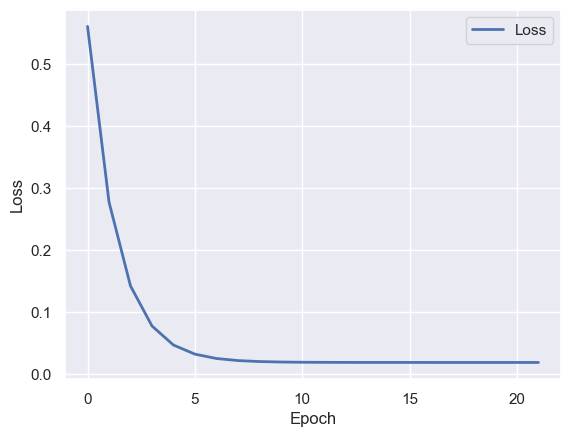

In [27]:
epoch = np.linspace(0, len(history_loss), num=len(history_loss)).astype('int')
# Define the loss for each step in list
step_loss = [ls[1] for ls in history_loss]

plt.plot(epoch, step_loss, lw=2, label='Loss')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.show()